# Parametric reconstruction

This is a very simple reconstruction fitting the data with a N-order polynomial

In [1]:
#General
import re
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from tools.samplers_interface import SamplersInterface 

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from scipy.interpolate import interp1d
from scipy.stats       import multivariate_normal
from itertools         import repeat

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

In [13]:
possible_derivatives = ['f','int','d1','d2']

# Settings

In [2]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 10

In [3]:
Nrecon = 10
xmin_recon = 0.
xmax_recon = 2.
x_recon = np.linspace(xmin_recon,xmax_recon,10)

x_label = r'$z$'
y_label = r'$f(z)$'

polynomial_order = [3,5,7]
sampler          = 'Nautilus'

In [4]:
from parametric_approach.polynomial import PolynomialFit

fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            'a3': -0.1}

theory = PolynomialFit(None,None,order=3)
theory_model = lambda x: theory.generate(x,[float(par) for par in fiducial.values()])

## Create data

In [5]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_model(dataset['x'])['f']
errors = abs(thvals)*err_fac/100
dataset['f'] = np.random.normal(thvals,errors)
dataset['f_err'] = errors

covmat = np.diag(errors*2)

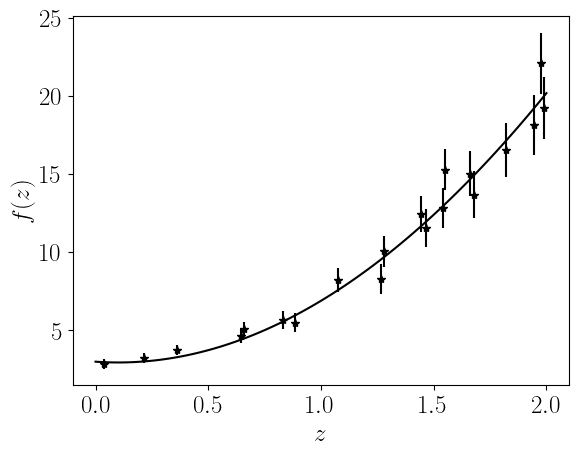

In [6]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
if theory_model != None:
    plt.plot(xplot,theory_model(xplot)['f'],color='black')
plt.errorbar(dataset['x'],dataset['f'],yerr=dataset['f_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

In [7]:
reconstructions = {}

In [8]:
from parametric_approach.polynomial import PolynomialFit

sampler = SamplersInterface(sampler=sampler,run_options='poor',chatty=False)

In [9]:
for order in polynomial_order:
    row = {'Info': {'Sampler': sampler}}
    
    paramtheory = PolynomialFit(dataset,covmat,order=order)
    model_params = {'a{}'.format(ind): {'prior': [-1000,1000],
                                        'latex': r'$a_{}$'.format(ind)} for ind in range(order+1)}
    row['Info']['Parameters'] = model_params
    
    raw_sample = sampler.run(model_params,paramtheory.likelihood)
    sample     = paramtheory.get_derived(raw_sample,x_recon,model_params)
    row['Info']['Sample'] = sample
    
    recon,cov_reco = paramtheory.get_reconstruction(sample,x_recon)
    row['Functions']   = pd.DataFrame(recon)
    row['Covariances'] = cov_reco

    reconstructions['Polynomial order {}'.format(order)] = row

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 46     | 1        | 2        | 29312    | N/A    | 10001 | -31.67   
Removed no burn in
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 57     | 1        | 2        | 36096    | N/A    | 10038 | -41.86   
Removed no burn in
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 65     | 1        | 2        | 41920    | N/A    | 10042 | -49.00   
Removed no burn in


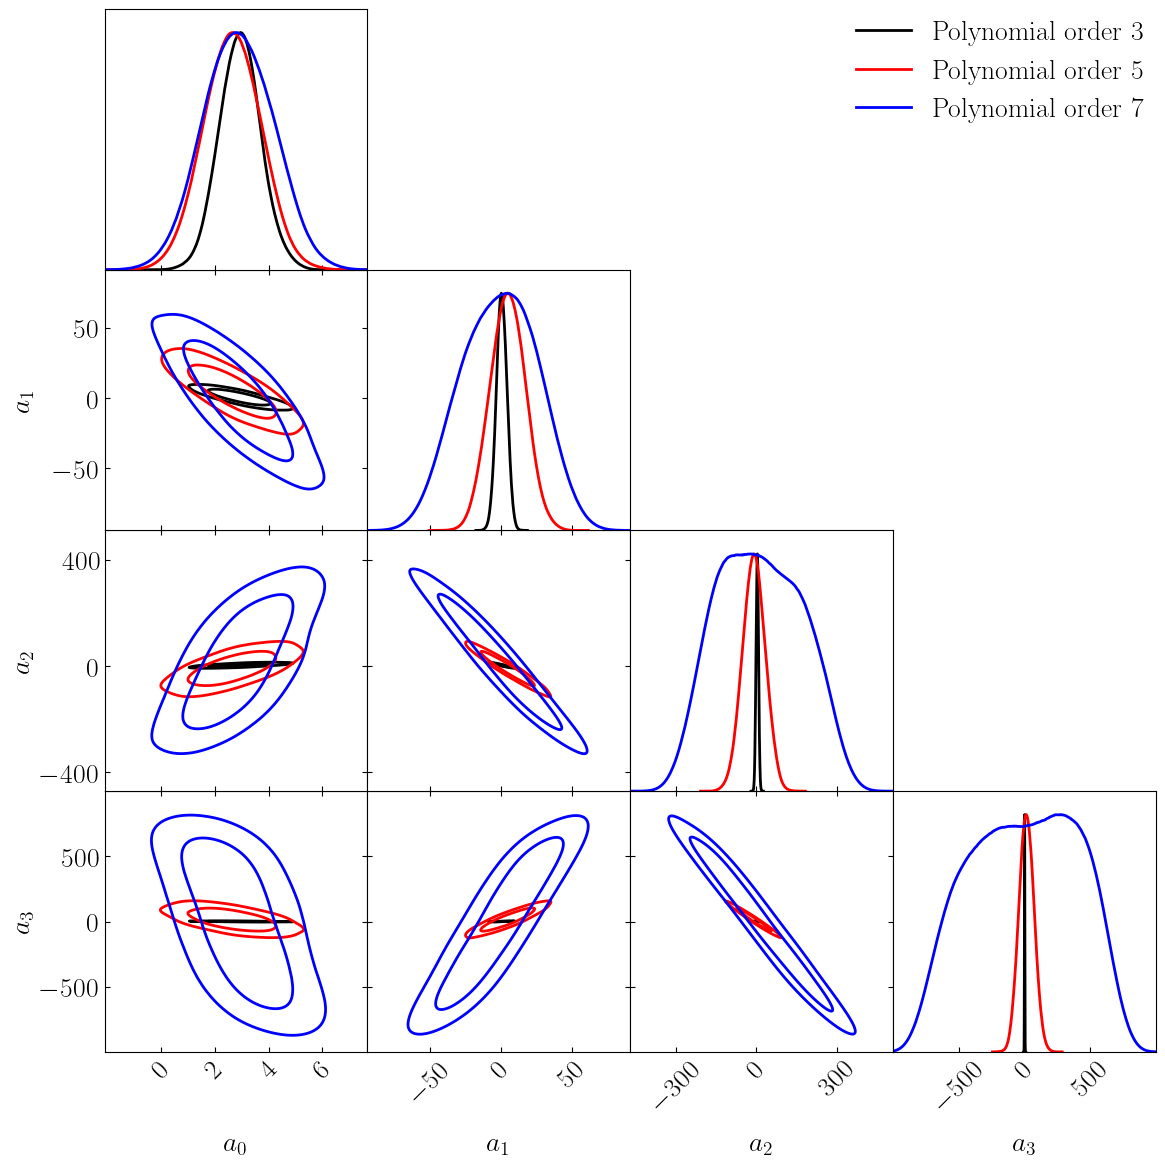

In [10]:
df = {k:v for k,v in reconstructions.items() if 'Polynomial' in k}

params  = [row['Info']['Parameters'] for row in df.values()][0]
samples = [row['Info']['Sample'] for row in df.values()]
labels  = list(df.keys())

g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot(samples,params,
                legend_labels=labels,legend_loc='upper right',
                filled=False,contour_lws=2,
               # markers=fiducial
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

In [11]:
dfs = []

for name,recon in reconstructions.items():
    df = pd.DataFrame(recon['Functions'])
    df['Method'] = name
    dfs.append(df)

results = pd.concat(dfs,ignore_index=True)

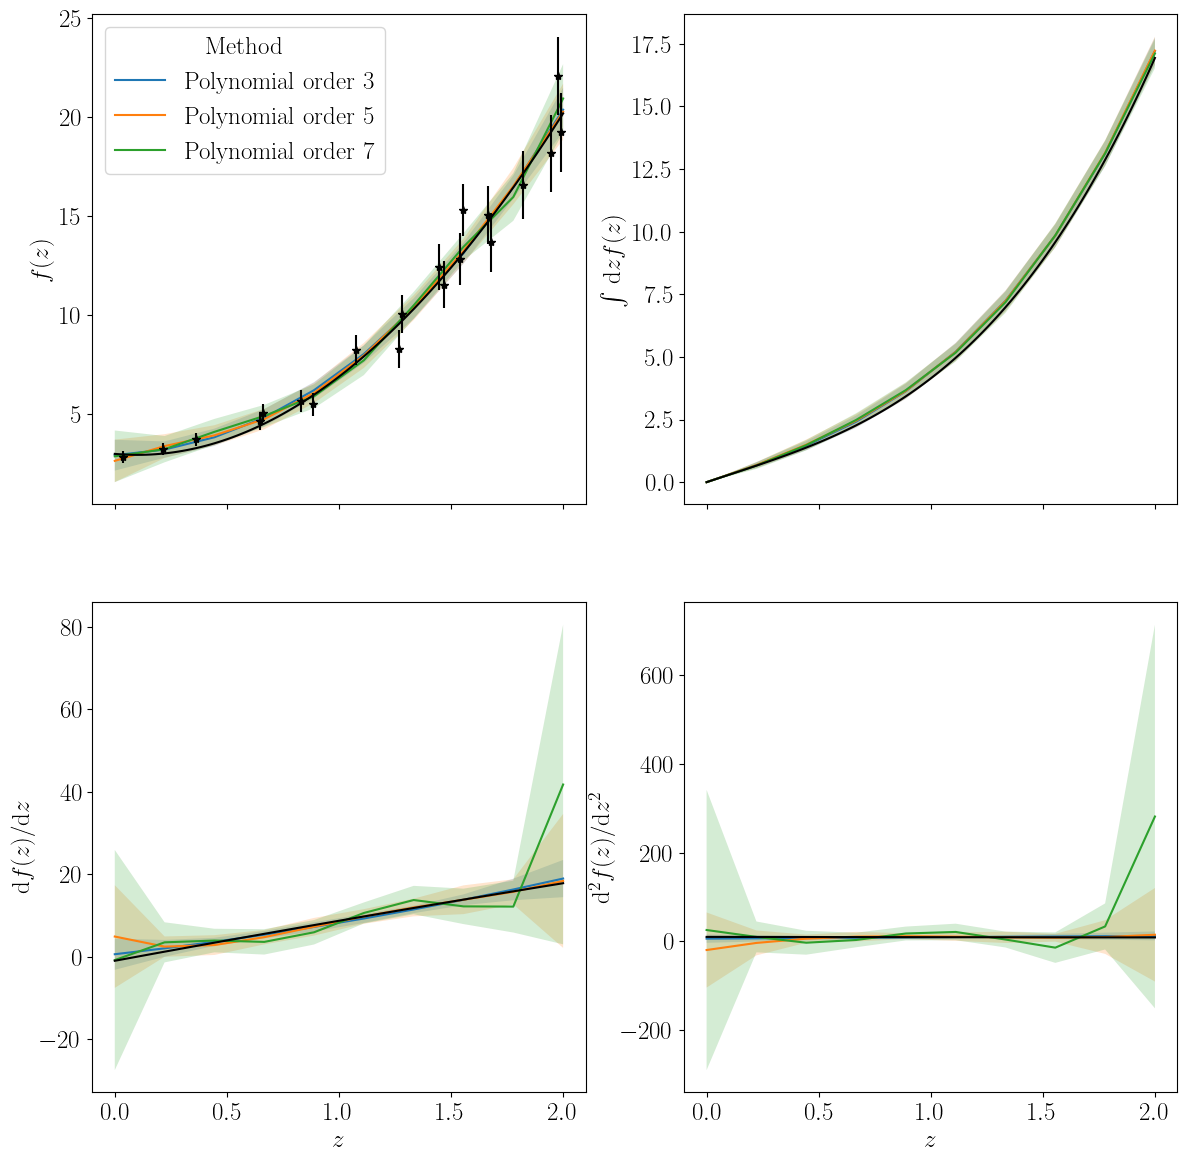

In [14]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for method in results['Method'].unique():
        df = results[results['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j])
    else:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j],legend=0)
    if theory_model != None:
        axes[i,j].plot(xplot,theory_model(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)